# Notebook 3B — Hyperparameter Tuning + SHAP
## BRFSS 2022 Heart Disease Prediction

**Input:** `brfss2022_clean.csv` from Notebook 1

**Pipeline:** Optuna → Tuned XGBoost → Threshold → SHAP

### Objectives
- Optimize XGBoost hyperparameter using **Optuna** (50 trials)
- Compare Baseline vs. Tuned XGBoost
- Analyze **Learning Curve** (check for overfitting)
- **SHAP** analysis — explain feature importance
- Compare with **GrowNet paper** benchmark

## 1. import the library

In [ ]:
!pip install -q imbalanced-learn xgboost shap optuna

import warnings, os, gc
warnings.filterwarnings('ignore')
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, StratifiedKFold,
    cross_val_score, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
try:
    import shap; SHAP_OK = True
except: SHAP_OK = False

SEED = 42
OUT  = '/content/nb3b_outputs'
os.makedirs(OUT, exist_ok=True)
print('✓ Libraries loaded')
print(f'  SHAP available: {SHAP_OK}')


✓ Libraries loaded
  SHAP available: True


## 2. Load & Setup (same as NB3A)

In [ ]:
from google.colab import files
uploaded = files.upload()
CLEAN_PATH = list(uploaded.keys())[0]

dm = pd.read_csv(CLEAN_PATH)
feat_cols = [c for c in dm.columns if c != 'target']

X = dm.drop(columns=['target'])
y = dm['target'].astype(int)
FEAT_NAMES = list(X.columns)

CONT_COLS = ['Sleep_hours', 'PhysHealth_days', 'MentHealth_days']
BIN_COLS  = [c for c in X.columns if c not in CONT_COLS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

SPW = (y_train==0).sum() / (y_train==1).sum()

preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), CONT_COLS),
], remainder='passthrough')

print(f'✓ Dataset: {len(dm):,} records  |  CVD rate: {dm["target"].mean()*100:.2f}%')
print(f'  Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'  scale_pos_weight: {SPW:.2f}')


Saving brfss2022_clean.csv to brfss2022_clean.csv
✓ Dataset: 340,154 records  |  CVD rate: 8.89%
  Train: 272,123  |  Test: 68,031
  scale_pos_weight: 10.24


## 3. Baseline XGBoost — Quick Recap

Train again at the baseline to compare with the tuned version.

In [ ]:
pipe_base = ImbPipeline([
    ('pre',   clone(preprocessor)),
    ('smote', SMOTE(random_state=SEED)),
    ('clf',   XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=SPW,
        objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', random_state=SEED, n_jobs=-1,
    )),
])
pipe_base.fit(X_train, y_train)
ypr_xgb = pipe_base.predict_proba(X_test)[:,1]

# G-mean threshold scan
rows = []
for t in np.arange(0.01, 1.00, 0.01):
    yt_ = (ypr_xgb >= t).astype(int)
    if yt_.sum() == 0: continue
    tn, fp, fn, tp_ = confusion_matrix(y_test, yt_).ravel()
    rec = tp_/(tp_+fn); spec = tn/(tn+fp)
    prec = precision_score(y_test, yt_, zero_division=0)
    gm = np.sqrt(rec*spec)
    fb2 = (1+4)*prec*rec/(4*prec+rec+1e-9)
    rows.append(dict(t=round(t,2), recall=rec, spec=spec, prec=prec, gm=gm, fb2=fb2))
td_base = pd.DataFrame(rows)
bgm_base = td_base.loc[td_base['gm'].idxmax()]
FINAL_T = float(bgm_base['t'])

print(f'✓ Baseline XGBoost fitted')
print(f'  G-mean threshold: {FINAL_T:.2f}')
print(f'  Sensitivity: {bgm_base.recall:.4f}  Specificity: {bgm_base.spec:.4f}  G-mean: {bgm_base.gm:.4f}')
print(f'  AUC: {roc_auc_score(y_test, ypr_xgb):.4f}')


✓ Baseline XGBoost fitted
  G-mean threshold: 0.66
  Sensitivity: 0.7787  Specificity: 0.7232  G-mean: 0.7505
  AUC: 0.8247


## 4. Optuna Hyperparameter Tuning — XGBoost

25 trials, optimizing **ROC-AUC** on a 5-fold CV.

In [ ]:
def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        gamma            = trial.suggest_float('gamma', 0.0, 5.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        scale_pos_weight = SPW,
        objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', random_state=SEED, n_jobs=-1,
    )
    pipe = ImbPipeline([
        ('pre',   clone(preprocessor)),
        ('smote', SMOTE(random_state=SEED)),
        ('clf',   XGBClassifier(**params))
    ])
    cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    return cross_val_score(pipe, X_train, y_train,
                           cv=cv5, scoring='roc_auc', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f'\nBest AUC (5-fold CV): {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k:25s}: {v}')


  0%|          | 0/25 [00:00<?, ?it/s]


Best AUC (5-fold CV): 0.8301
Best params:
  n_estimators             : 533
  max_depth                : 3
  learning_rate            : 0.20620175200624824
  subsample                : 0.9639722441294497
  colsample_bytree         : 0.7324157645057991
  min_child_weight         : 8
  gamma                    : 1.203538805551276
  reg_alpha                : 0.008696836819616664
  reg_lambda               : 0.1506800396975009


## 5. Train Tuned XGBoost

In [ ]:
best_p = study.best_params.copy()
best_p.update({'scale_pos_weight': SPW, 'objective': 'binary:logistic',
               'eval_metric': 'logloss', 'tree_method': 'hist',
               'random_state': SEED, 'n_jobs': -1})

xgb_tuned = ImbPipeline([
    ('pre',   clone(preprocessor)),
    ('smote', SMOTE(random_state=SEED)),
    ('clf',   XGBClassifier(**best_p))
])
xgb_tuned.fit(X_train, y_train)
ypr_tuned = xgb_tuned.predict_proba(X_test)[:,1]

print(f'✓ Tuned XGBoost fitted')
print(f'  AUC (test): {roc_auc_score(y_test, ypr_tuned):.4f}')


✓ Tuned XGBoost fitted
  AUC (test): 0.8300


## 6. Threshold Scan — Tuned XGBoost

In [ ]:
rows_t = []
for t in np.arange(0.01, 1.0, 0.01):
    yt_ = (ypr_tuned >= t).astype(int)
    if yt_.sum() == 0: continue
    tn, fp, fn, tp_ = confusion_matrix(y_test, yt_).ravel()
    rec  = tp_/(tp_+fn); spec = tn/(tn+fp)
    prec = precision_score(y_test, yt_, zero_division=0)
    f1   = f1_score(y_test, yt_, zero_division=0)
    gm   = np.sqrt(rec*spec)
    fb2  = (1+4)*prec*rec/(4*prec+rec+1e-9)
    rows_t.append(dict(t=round(t,2), recall=rec, spec=spec,
                       prec=prec, f1=f1, gm=gm, fb2=fb2))

td_t = pd.DataFrame(rows_t)
bgm_t = td_t.loc[td_t['gm'].idxmax()]
FINAL_T_TUNED = float(bgm_t['t'])

print(f'Tuned XGBoost @ G-mean threshold={FINAL_T_TUNED:.2f}:')
print(f'  Sensitivity={bgm_t.recall:.4f}  Specificity={bgm_t.spec:.4f}  G-mean={bgm_t.gm:.4f}')
print(f'  AUC={roc_auc_score(y_test, ypr_tuned):.4f}')


Tuned XGBoost @ G-mean threshold=0.58:
  Sensitivity=0.7855  Specificity=0.7251  G-mean=0.7547
  AUC=0.8300


## 7. Baseline vs Tuned XGBoost Comparison

=== So sánh Baseline vs Tuned XGBoost ===
Metric          | Baseline @0.66       | Tuned @0.58          | GrowNet paper
---------------------------------------------------------------------------
Sensitivity     |               0.7787 |               0.7855 | 0.810  Δ=+0.0068
Specificity     |               0.7232 |               0.7251 | 0.740  Δ=+0.0019
G-mean          |               0.7505 |               0.7547 | 0.774  Δ=+0.0042
AUC             |               0.8247 |               0.8300 | 0.871  Δ=+0.0053
Fbeta2          |               0.5114 |               0.5167 | N/A    Δ=+0.0053


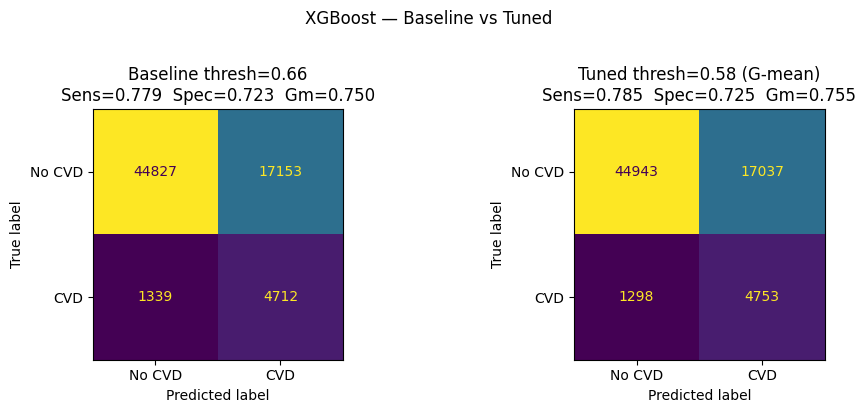

In [ ]:
print('=== compare Baseline vs Tuned XGBoost ===')
print(f'{"Metric":15s} | {"Baseline @"+str(FINAL_T)[:4]:20s} | {"Tuned @"+str(FINAL_T_TUNED)[:4]:20s} | {"GrowNet paper"}')
print('-'*75)

yp_base  = (ypr_xgb   >= FINAL_T).astype(int)
yp_tuned = (ypr_tuned >= FINAL_T_TUNED).astype(int)
tn1,fp1,fn1,tp1 = confusion_matrix(y_test, yp_base).ravel()
tn2,fp2,fn2,tp2 = confusion_matrix(y_test, yp_tuned).ravel()

metrics_cmp = [
    ('Sensitivity', tp1/(tp1+fn1),   tp2/(tp2+fn2),   0.810),
    ('Specificity', tn1/(tn1+fp1),   tn2/(tn2+fp2),   0.740),
    ('G-mean',      np.sqrt(tp1/(tp1+fn1)*tn1/(tn1+fp1)),
                    np.sqrt(tp2/(tp2+fn2)*tn2/(tn2+fp2)), 0.774),
    ('AUC',         roc_auc_score(y_test, ypr_xgb),
                    roc_auc_score(y_test, ypr_tuned),  0.871),
    ('Fbeta2',
        (1+4)*precision_score(y_test,yp_base,zero_division=0)*recall_score(y_test,yp_base,zero_division=0)/
        (4*precision_score(y_test,yp_base,zero_division=0)+recall_score(y_test,yp_base,zero_division=0)+1e-9),
        (1+4)*precision_score(y_test,yp_tuned,zero_division=0)*recall_score(y_test,yp_tuned,zero_division=0)/
        (4*precision_score(y_test,yp_tuned,zero_division=0)+recall_score(y_test,yp_tuned,zero_division=0)+1e-9),
        -1),
]

for nm, base, tuned, paper in metrics_cmp:
    pstr  = f'{paper:.3f}' if paper > 0 else 'N/A  '
    delta = f'{tuned-base:+.4f}'
    print(f'{nm:15s} | {base:20.4f} | {tuned:20.4f} | {pstr}  Δ={delta}')

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, yp, title in zip(axes,
    [yp_base, yp_tuned],
    [f'Baseline thresh={FINAL_T:.2f}', f'Tuned thresh={FINAL_T_TUNED:.2f} (G-mean)']):
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['No CVD','CVD']).plot(
        ax=ax, values_format='d', colorbar=False)
    rec  = recall_score(y_test, yp, zero_division=0)
    spec = cm[0,0]/(cm[0,0]+cm[0,1])
    gm   = np.sqrt(rec*spec)
    ax.set_title(f'{title}\nSens={rec:.3f}  Spec={spec:.3f}  Gm={gm:.3f}')
plt.suptitle('XGBoost — Baseline vs Tuned', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(f'{OUT}/confusion_baseline_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Learning Curve — Check for Overfitting


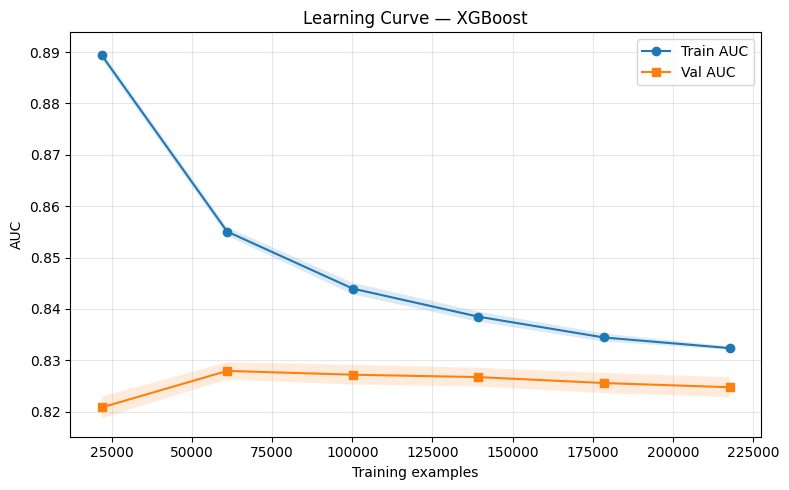

Train AUC @ full data: 0.8324 ± 0.0003
Val   AUC @ full data: 0.8248 ± 0.0019
Gap (overfit indicator): 0.0076  → OK


In [ ]:
xgb_lc = clone(pipe_base)
train_sizes, train_scores, val_scores = learning_curve(
    xgb_lc, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1
)

tm, ts = train_scores.mean(1), train_scores.std(1)
vm, vs = val_scores.mean(1),   val_scores.std(1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, tm, 'o-', label='Train AUC')
ax.plot(train_sizes, vm, 's-', label='Val AUC')
ax.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.15)
ax.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.15)
ax.set_xlabel('Training examples'); ax.set_ylabel('AUC')
ax.set_title('Learning Curve — XGBoost')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(f'{OUT}/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Train AUC @ full data: {tm[-1]:.4f} ± {ts[-1]:.4f}')
print(f'Val   AUC @ full data: {vm[-1]:.4f} ± {vs[-1]:.4f}')
gap = tm[-1] - vm[-1]
print(f'Gap (overfit indicator): {gap:.4f}  →', 'OK' if gap < 0.05 else 'Possible overfitting')


## 9. SHAP Analysis — Tuned XGBoost

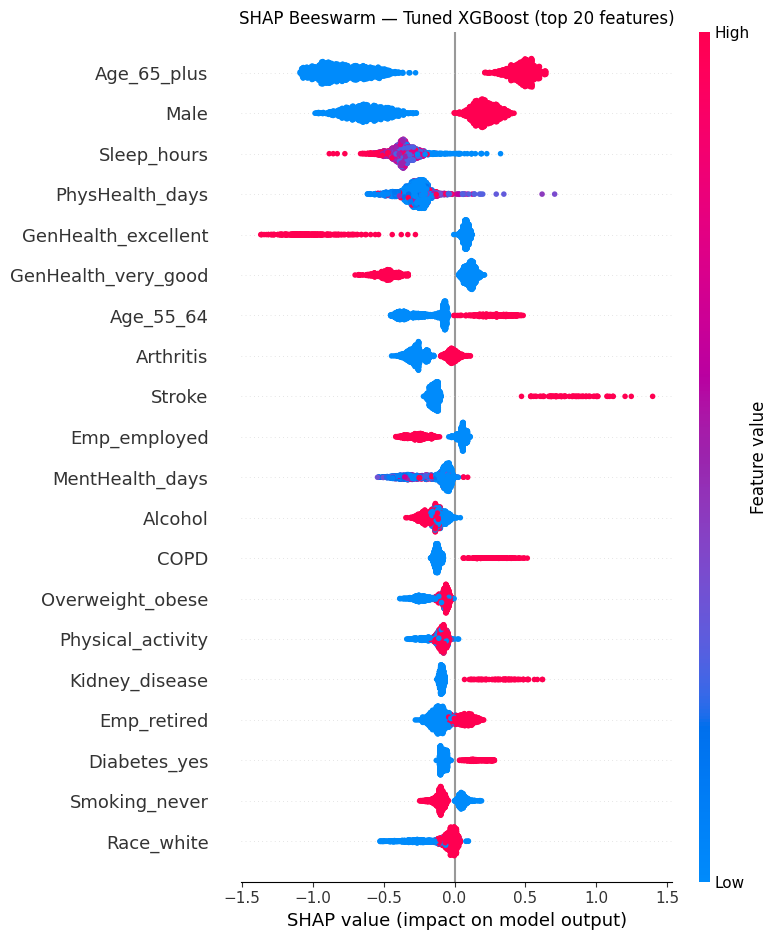

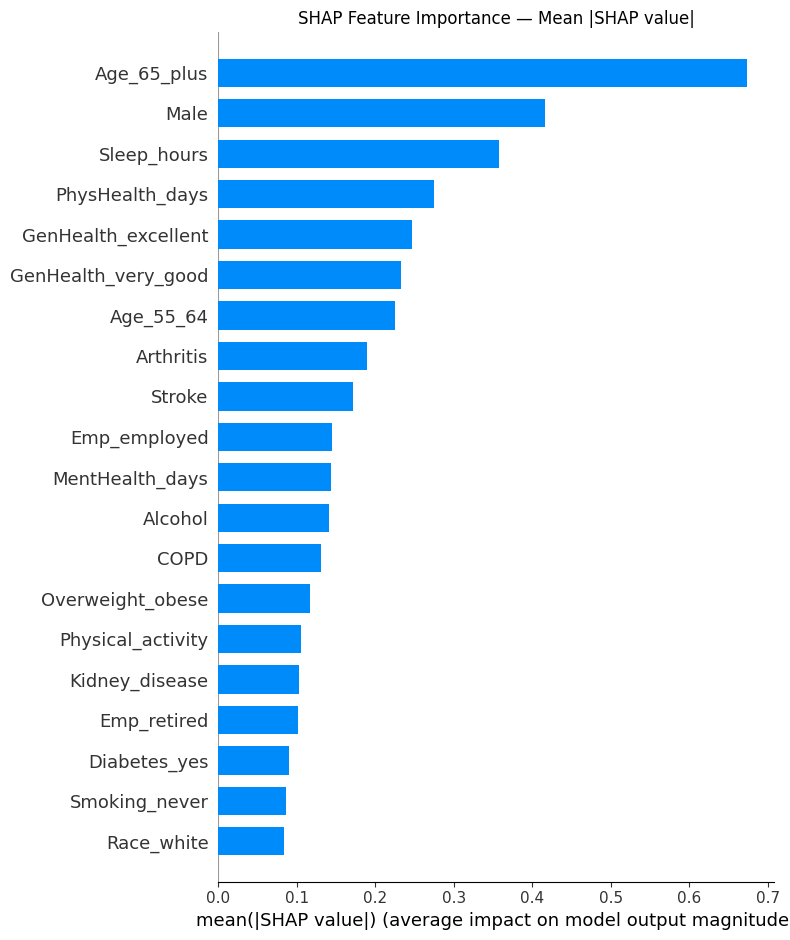


Top 5 features by mean |SHAP|:
  Age_65_plus                   : 0.6737
  Male                          : 0.4159
  Sleep_hours                   : 0.3574
  PhysHealth_days               : 0.2745
  GenHealth_excellent           : 0.2465


In [ ]:
if not SHAP_OK:
    print('SHAP is unavailable — run: !pip install shap')
else:
    pre_fit = xgb_tuned.named_steps['pre']
    clf_fit = xgb_tuned.named_steps['clf']
    X_test_enc = pre_fit.transform(X_test)
    clean_names = CONT_COLS + BIN_COLS

    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X_test_enc), size=min(2000, len(X_test_enc)), replace=False)
    X_shap = X_test_enc[idx]

    explainer   = shap.TreeExplainer(clf_fit)
    shap_values = explainer.shap_values(X_shap)

    # Beeswarm plot
    plt.figure(figsize=(10, 10))
    shap.summary_plot(shap_values, X_shap, feature_names=clean_names,
                      max_display=20, show=False)
    plt.title('SHAP Beeswarm — Tuned XGBoost (top 20 features)')
    plt.tight_layout()
    plt.savefig(f'{OUT}/shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bar plot — mean |SHAP|
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_shap, feature_names=clean_names,
                      plot_type='bar', max_display=20, show=False)
    plt.title('SHAP Feature Importance — Mean |SHAP value|')
    plt.tight_layout()
    plt.savefig(f'{OUT}/shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Top 5 features
    mean_shap = np.abs(shap_values).mean(0)
    top5 = pd.Series(mean_shap, index=clean_names).sort_values(ascending=False).head(5)
    print('\nTop 5 features by mean |SHAP|:')
    for feat, val in top5.items():
        print(f'  {feat:30s}: {val:.4f}')


## 10. Final Summary

In [ ]:
print('='*65)
print('FINAL SUMMARY — BRFSS 2022 Heart Disease Prediction')
print('='*65)
print(f'Dataset  : {len(dm):,} records  |  CVD rate: {dm["target"].mean()*100:.2f}%')
print(f'Features : {len(feat_cols)} cols')
print(f'Split    : 80/20 stratified')
print(f'Pipeline : Preprocessor → SMOTE → XGBoost (ImbPipeline)')
print(f'Tuning   : Optuna {len(study.trials)} trials  |  Best CV AUC: {study.best_value:.4f}')
print()
print('── Tuned XGBoost @ G-mean threshold ──')
print(f'  Threshold   : {FINAL_T_TUNED:.2f} (G-mean optimal)')
print(f'  Sensitivity : {bgm_t.recall:.4f}')
print(f'  Specificity : {bgm_t.spec:.4f}')
print(f'  G-mean      : {bgm_t.gm:.4f}')
print(f'  AUC         : {roc_auc_score(y_test, ypr_tuned):.4f}')
print(f'  F-beta2     : {bgm_t.fb2:.4f}')
print()
print('── So sánh với GrowNet paper ──')
print(f'  Sensitivity: {bgm_t.recall:.4f} vs 0.810 (paper)  Δ={bgm_t.recall-0.810:+.4f}')
print(f'  Specificity: {bgm_t.spec:.4f} vs 0.740 (paper)  Δ={bgm_t.spec-0.740:+.4f}')
print(f'  G-mean     : {bgm_t.gm:.4f} vs 0.774 (paper)  Δ={bgm_t.gm-0.774:+.4f}')
print(f'  AUC        : {roc_auc_score(y_test, ypr_tuned):.4f} vs 0.871 (paper)  Δ={roc_auc_score(y_test, ypr_tuned)-0.871:+.4f}')
print()
print(f'📁 Outputs: {OUT}/')
for f in sorted(os.listdir(OUT)):
    print(f'  {f}')


FINAL SUMMARY — BRFSS 2022 Heart Disease Prediction
Dataset  : 340,154 records  |  CVD rate: 8.89%
Features : 50 cols
Split    : 80/20 stratified
Pipeline : Preprocessor → SMOTE → XGBoost (ImbPipeline)
Tuning   : Optuna 25 trials  |  Best CV AUC: 0.8301

── Tuned XGBoost @ G-mean threshold ──
  Threshold   : 0.58 (G-mean optimal)
  Sensitivity : 0.7855
  Specificity : 0.7251
  G-mean      : 0.7547
  AUC         : 0.8300
  F-beta2     : 0.5167

── So sánh với GrowNet paper ──
  Sensitivity: 0.7855 vs 0.810 (paper)  Δ=-0.0245
  Specificity: 0.7251 vs 0.740 (paper)  Δ=-0.0149
  G-mean     : 0.7547 vs 0.774 (paper)  Δ=-0.0193
  AUC        : 0.8300 vs 0.871 (paper)  Δ=-0.0410

📁 Outputs: /content/nb3b_outputs/
  confusion_baseline_vs_tuned.png
  learning_curve.png
  shap_bar.png
  shap_beeswarm.png
